
WeibullAFT Summary:
                       coef  exp(coef)  se(coef)  coef lower 95%  \
param   covariate                                                  
lambda_ ID        -0.000481   0.999519  0.000189       -0.000853   
        address    0.044491   1.045496  0.009130        0.026596   
        age        0.029602   1.030044  0.006991        0.015899   
        custcat    0.335753   1.398993  0.073240        0.192205   
        ed         0.055912   1.057504  0.035650       -0.013961   
        forward   -0.325722   0.722006  0.142854       -0.605710   
        gender    -0.051674   0.949639  0.106568       -0.260542   
        income     0.000769   1.000770  0.000865       -0.000925   
        internet  -0.792940   0.452512  0.120931       -1.029960   
        marital   -0.409163   0.664206  0.107169       -0.619210   
        region     0.073244   1.075993  0.063785       -0.051772   
        retire     0.211202   1.235161  0.539911       -0.847005   
        voice     -0.424664

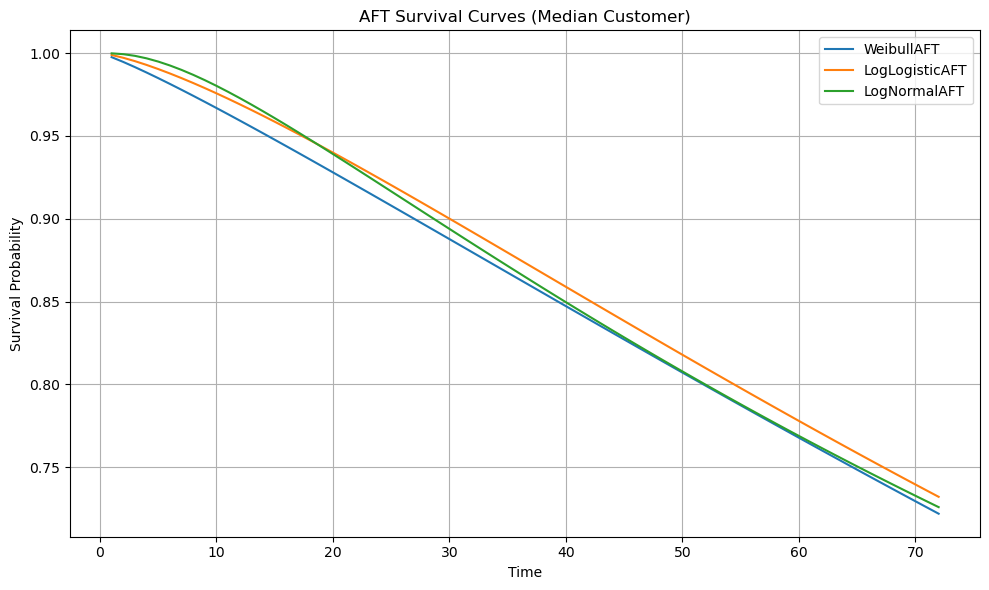

Final Model Selected: LogNormalAFT


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import WeibullAFTFitter, LogLogisticAFTFitter, LogNormalAFTFitter
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("telco.csv")

df_encoded = df.copy()
df_encoded["churn"] = df_encoded["churn"].map({"Yes": 1, "No": 0})

for col in df_encoded.select_dtypes(include="object").columns:
    if col not in ["ID"]:
        df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

duration_col = "tenure"
event_col = "churn"

models = {
    "WeibullAFT": WeibullAFTFitter(),
    "LogLogisticAFT": LogLogisticAFTFitter(),
    "LogNormalAFT": LogNormalAFTFitter()
}

aic_scores = {}
fitted_models = {}

for name, model in models.items():
    model.fit(df_encoded, duration_col=duration_col, event_col=event_col)
    aic_scores[name] = model.AIC_
    fitted_models[name] = model
    print(f"\n{name} Summary:")
    print(model.summary)

print("\nAIC Scores:")
for name, aic in aic_scores.items():
    print(f"{name}: {aic}")

from lifelines.plotting import plot_lifetimes
import numpy as np

plt.figure(figsize=(10, 6))
for name, model in fitted_models.items():
    surv = model.predict_survival_function(df_encoded.median().to_frame().T)
    plt.plot(surv.index, surv.values.flatten(), label=name)

plt.title("AFT Survival Curves (Median Customer)")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

best_model_name = min(aic_scores, key=aic_scores.get)
final_model = fitted_models[best_model_name]
print(f"\n Final Model Selected: {best_model_name}")

In [5]:
from lifelines import LogNormalAFTFitter

final_model = LogNormalAFTFitter()
final_model.fit(df_encoded, duration_col="tenure", event_col="churn")

predicted_lifetime = final_model.predict_median(df_encoded)

monthly_revenue = 50     
discount_rate = 0.01      # monthly discount rate (e.g., 1%)

clv = (monthly_revenue * (1 - (1 + discount_rate) ** (-predicted_lifetime))) / discount_rate

df_encoded["predicted_lifetime"] = predicted_lifetime
df_encoded["CLV"] = clv

df_clv_segments = df_encoded[["ID", "region", "custcat", "income", "CLV"]]